# Chapter 14 - K-Nearest Neighbors

K-Nearest Neighbors, or KNN, is one of the simplest Machine Learning algorithms. It stores the training data and predicts a new point by looking at the nearest examples around it.

In this chapter we move from the basic intuition to classification, regression, K selection, weighted KNN, and practical limitations.

## Step 1 - KNN for Classification

Imagine we have student data with two features: `IQ` and `CGPA`. The target tells
us whether each student was placed or not placed.

For a new student, KNN follows three simple steps:

1. Choose a value of K.
2. Find the K nearest training examples.
3. Let those neighbors vote for the predicted class.

We will use a tiny toy dataset so the voting logic is easy to inspect.


In [17]:
import math

import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_wine
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

# Each row stores [IQ, CGPA].
student_features = np.array([
    [96, 6.1],
    [101, 6.4],
    [104, 6.9],
    [109, 7.6],
    [112, 8.0],
    [116, 8.4],
    [122, 8.8],
    [125, 9.1],
])

# 0 means not placed, and 1 means placed.
student_labels = np.array([0, 0, 0, 0, 1, 1, 1, 1])
query_student = np.array([[108 , 7.4]])

print("Student feature matrix shape:", student_features.shape)
print("Target labels:", student_labels)

# query is the input for which we try to predict the result via our KNN model
print("Query student [IQ, CGPA]:", query_student[0])


Student feature matrix shape: (8, 2)
Target labels: [0 0 0 0 1 1 1 1]
Query student [IQ, CGPA]: [108.    7.4]


Before predicting with a library, we calculate the distances ourselves. This shows
the exact idea behind KNN: the closest points get inspected first.


In [18]:
k = 5

distances = np.linalg.norm(student_features - query_student, axis=1)
nearest_indices = np.argsort(distances)[:k]
nearest_labels = student_labels[nearest_indices]

print("Distances from the query student:")
for index, distance in enumerate(distances):
    print(f"Student {index}: distance = {distance:.2f}, label = {student_labels[index]}")

print("\nNearest neighbor indices:", nearest_indices)
print("Nearest neighbor labels:", nearest_labels)
print("\nPlaced votes:", np.sum(nearest_labels == 1))
print("Not placed votes:", np.sum(nearest_labels == 0))

manual_prediction = int(np.mean(nearest_labels) >= 0.5)
print("\nManual KNN prediction:", "Placed" if manual_prediction == 1 else "Not placed")


Distances from the query student:
Student 0: distance = 12.07, label = 0
Student 1: distance = 7.07, label = 0
Student 2: distance = 4.03, label = 0
Student 3: distance = 1.02, label = 0
Student 4: distance = 4.04, label = 1
Student 5: distance = 8.06, label = 1
Student 6: distance = 14.07, label = 1
Student 7: distance = 17.08, label = 1

Nearest neighbor indices: [3 2 4 1 5]
Nearest neighbor labels: [0 0 1 0 1]

Placed votes: 2
Not placed votes: 3

Manual KNN prediction: Not placed


The query point is classified by majority vote. In this example, most of the five
closest points belong to class `0`, so the new student is predicted as not placed.


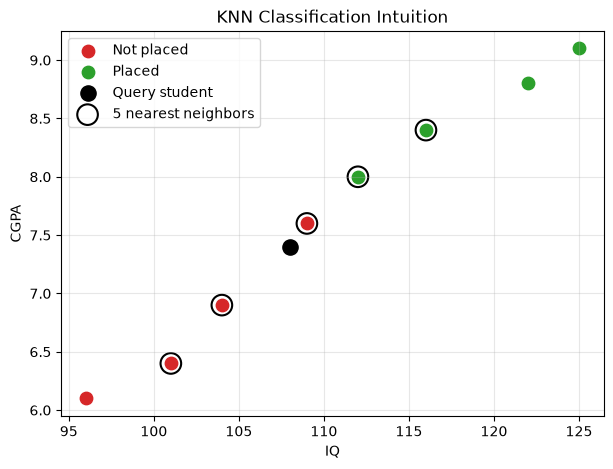

In [3]:
plt.figure(figsize=(7, 5))
plt.scatter(
    student_features[student_labels == 0, 0],
    student_features[student_labels == 0, 1],
    label="Not placed",
    color="tab:red",
    s=80,
)
plt.scatter(
    student_features[student_labels == 1, 0],
    student_features[student_labels == 1, 1],
    label="Placed",
    color="tab:green",
    s=80,
)
plt.scatter(query_student[:, 0], query_student[:, 1], label="Query student", color="black", s=120)
plt.scatter(
    student_features[nearest_indices, 0],
    student_features[nearest_indices, 1],
    facecolors="none",
    edgecolors="black",
    s=220,
    linewidths=1.5,
    label="5 nearest neighbors",
)
plt.title("KNN Classification Intuition")
plt.xlabel("IQ")
plt.ylabel("CGPA")
plt.legend()
plt.grid(alpha=0.3)
plt.show(block=False)
plt.close()


## Step 2 - Applying KNN to Higher Dimensions

The graph above used only two features, so we could draw the points on a plane.

Real datasets may contain many features such as IQ, CGPA, study hours,
internship experience, and communication score.

KNN does not change its logic. It still measures distance between points, only now
the distance is calculated across all available features.


In [ ]:
higher_dim_students = np.array([
    [96, 6.1, 2, 0, 5],
    [101, 6.4, 3, 0, 6],
    [109, 7.6, 5, 1, 7],
    [116, 8.4, 6, 1, 8],
    [122, 8.8, 7, 2, 9],
])

# query is the input for which we try to predict the result via our KNN model
higher_dim_query = np.array([[110, 7.7, 5, 1, 7]])
higher_dim_distances = np.linalg.norm(higher_dim_students - higher_dim_query, axis=1)

print("Distances in 5-dimensional feature space:")
for index, distance in enumerate(higher_dim_distances):
    print(f"Student {index}: distance = {distance:.2f}")

print("\nClosest student index:", np.argmin(higher_dim_distances))


Distances in 5-dimensional feature space:
Student 0: distance = 14.58
Student 1: distance = 9.42
Student 2: distance = 1.00
Student 3: distance = 6.20
Student 4: distance = 12.42

Closest student index: 2


We cannot easily visualize five dimensions, but the calculation is the same. 

Since each feature contributes to the final distance, so feature scaling becomes important
when features have very different numeric ranges.


## Step 3 - KNN for Regression

KNN can also predict a number. Classification uses majority voting, while
regression takes the average value of the nearest neighbors.

Suppose the nearest three students have first-year salaries of 6, 8, and 7 lakhs.
KNN regression predicts the average of those values.


In [5]:
nearest_salaries_lakhs = np.array([6, 8, 7])
predicted_salary = nearest_salaries_lakhs.mean()

print("Nearest salaries in lakhs:", nearest_salaries_lakhs)
print(f"Predicted salary: {predicted_salary:.1f} lakhs")


Nearest salaries in lakhs: [6 8 7]
Predicted salary: 7.0 lakhs


The idea is almost identical to classification. 

The only difference is the final aggregation step: 
- vote for a class in classification
- average the target values in regression


## Step 4 - Implementing KNN on the Wine Dataset

Now we will implement KNN with Scikit-learn on the Wine dataset. 

Each wine is described by chemical measurements, and the target tells us which cultivar the wine
belongs to.

Since KNN depends on distances, we will first inspect the raw feature ranges, then
standardize the features before fitting the classifier.


In [6]:
# load the wine dataset
wine = load_wine()
X = wine.data
y = wine.target

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)
print("\nClass names:", wine.target_names)
print("\nFirst five feature names:", wine.feature_names[:5])
print("\nFirst row before scaling:")
print(np.round(X[0], 2))


Feature matrix shape: (178, 13)
Target vector shape: (178,)

Class names: ['class_0' 'class_1' 'class_2']

First five feature names: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium']

First row before scaling:
[1.423e+01 1.710e+00 2.430e+00 1.560e+01 1.270e+02 2.800e+00 3.060e+00
 2.800e-01 2.290e+00 5.640e+00 1.040e+00 3.920e+00 1.065e+03]


We split the dataset into training and testing sets. The training set is used to
store the examples KNN will search through. The test set is kept aside for final
checking.


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])


Training rows: 142
Testing rows: 36


Before scaling, some features have much larger values than others. If we use raw
distances, those large-range features dominate the neighbor search. StandardScaler
puts every feature on a comparable scale.


In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("First training row before scaling:")
print(np.round(X_train[0], 2))

print("\nSame row after scaling:")
print(np.round(X_train_scaled[0], 2))


First training row before scaling:
[1.328e+01 1.640e+00 2.840e+00 1.550e+01 1.100e+02 2.600e+00 2.680e+00
 3.400e-01 1.360e+00 4.600e+00 1.090e+00 2.780e+00 8.800e+02]

Same row after scaling:
[ 0.39 -0.64  1.78 -1.22  0.7   0.53  0.73 -0.17 -0.42 -0.17  0.62  0.25
  0.47]


Now we train a KNN classifier with `K = 5`, make predictions on the test set, and
calculate accuracy.


In [9]:
knn_classifier = KNeighborsClassifier(n_neighbors=5)
knn_classifier.fit(X_train_scaled, y_train)

y_pred = knn_classifier.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)

print(f"KNN classification accuracy: {accuracy:.2f}")
print("First 10 actual labels:   ", y_test[:10])
print("First 10 predicted labels:", y_pred[:10])


KNN classification accuracy: 0.97
First 10 actual labels:    [0 2 0 1 1 0 0 1 1 2]
First 10 predicted labels: [0 2 0 1 1 0 0 1 1 2]


The model is not learning coefficients. It is keeping the training examples and
using them as neighbors whenever a new wine sample needs a prediction.


## Step 5 - Using KNN for Regression in Scikit-learn

Scikit-learn also provides `KNeighborsRegressor`. 

Here we use the Wine target as a simple numeric example
only to demonstrate the API.


In [10]:
knn_regressor = KNeighborsRegressor(n_neighbors=5)
knn_regressor.fit(X_train_scaled, y_train)

y_pred_regression = knn_regressor.predict(X_test_scaled)

print("First 10 regressor outputs:")
print(np.round(y_pred_regression[:10], 2))


First 10 regressor outputs:
[0.  1.6 0.  0.6 1.  0.  0.  0.8 1.  2. ]


A real regression task would use a continuous target such as salary, price, or
demand. 

The important point here is the fact that - classifier predicts classes, regressor
predicts averaged numeric values.


## Step 6 - Choosing the Right Value of K


We have two practical ways to choose K:

- start with a heuristic such as the square root of the number of training rows
- try several K values and compare their validation or test accuracy

We will do both on the Wine dataset.


In [11]:
def nearest_odd_number(value):
    rounded = int(round(value))
    if rounded % 2 == 0:
        rounded += 1
    return max(1, rounded)

sqrt_k = nearest_odd_number(math.sqrt(X_train_scaled.shape[0]))
print("Training rows:", X_train_scaled.shape[0])
print("Square-root heuristic K:", sqrt_k)


Training rows: 142
Square-root heuristic K: 13


K values tested: [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25]
Accuracy values: [0.972, 0.972, 0.972, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
Best K in this run: 7 with accuracy 1.00


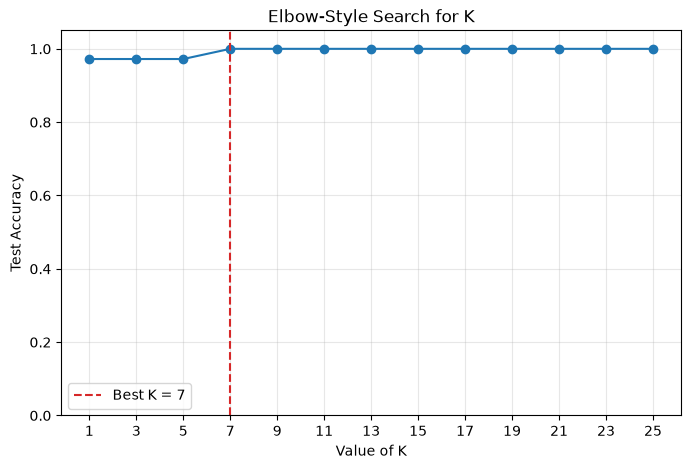

In [12]:
k_values = list(range(1, 26, 2))
accuracies = []

for current_k in k_values:
    model = KNeighborsClassifier(n_neighbors=current_k)
    model.fit(X_train_scaled, y_train)
    current_predictions = model.predict(X_test_scaled)
    accuracies.append(accuracy_score(y_test, current_predictions))

best_index = int(np.argmax(accuracies))
best_k = k_values[best_index]

print("K values tested:", k_values)
print("Accuracy values:", [round(score, 3) for score in accuracies])
print(f"Best K in this run: {best_k} with accuracy {accuracies[best_index]:.2f}")

plt.figure(figsize=(8, 5))
plt.plot(k_values, accuracies, marker="o")
plt.axvline(best_k, color="tab:red", linestyle="--", label=f"Best K = {best_k}")
plt.title("Elbow-Style Search for K")
plt.xlabel("Value of K")
plt.ylabel("Test Accuracy")
plt.xticks(k_values)
plt.ylim(0.0, 1.05)
plt.grid(alpha=0.3)
plt.legend()
plt.show(block=False)
plt.close()


A single train-test split is enough for a teaching example, but in a real project
we would usually choose K with cross-validation so the choice is less dependent on
one particular split.


## Step 7 - Effect of K in KNN

K controls how local or global the decision is.

- Small K values are very sensitive to nearby points and can overfit.
- Large K values are smoother but can underfit.
- Medium K values often give a better trade-off.

Lets demonstrate this with two overlapping classes containing 201 points in one
class and 199 in the other. 

We will firstly create setup with synthetic data and then inspect the decision boundary for different values of K.


Class 0 count: 201
Class 1 count: 199
Total points: 400


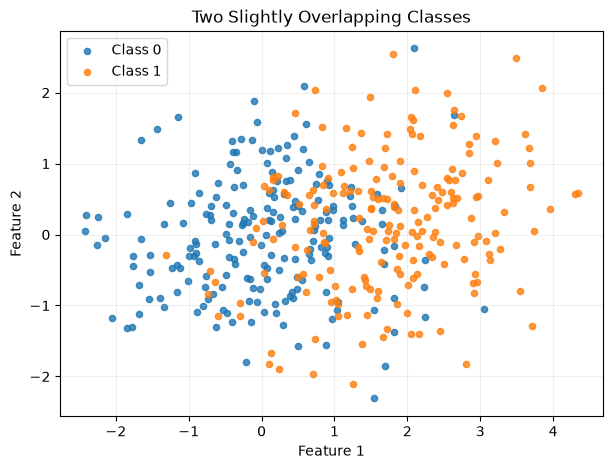

In [13]:
rng = np.random.default_rng(42)
blue_points = rng.normal(loc=[0.0, 0.0], scale=[1.05, 0.9], size=(201, 2))
orange_points = rng.normal(loc=[1.8, 0.2], scale=[1.05, 0.9], size=(199, 2))

X_boundary = np.vstack([blue_points, orange_points])
y_boundary = np.array([0] * len(blue_points) + [1] * len(orange_points))

print("Class 0 count:", np.sum(y_boundary == 0))
print("Class 1 count:", np.sum(y_boundary == 1))
print("Total points:", len(y_boundary))

plt.figure(figsize=(7, 5))
plt.scatter(blue_points[:, 0], blue_points[:, 1], s=20, label="Class 0", alpha=0.8)
plt.scatter(orange_points[:, 0], orange_points[:, 1], s=20, label="Class 1", alpha=0.8)
plt.title("Two Slightly Overlapping Classes")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(alpha=0.2)
plt.show(block=False)
plt.close()


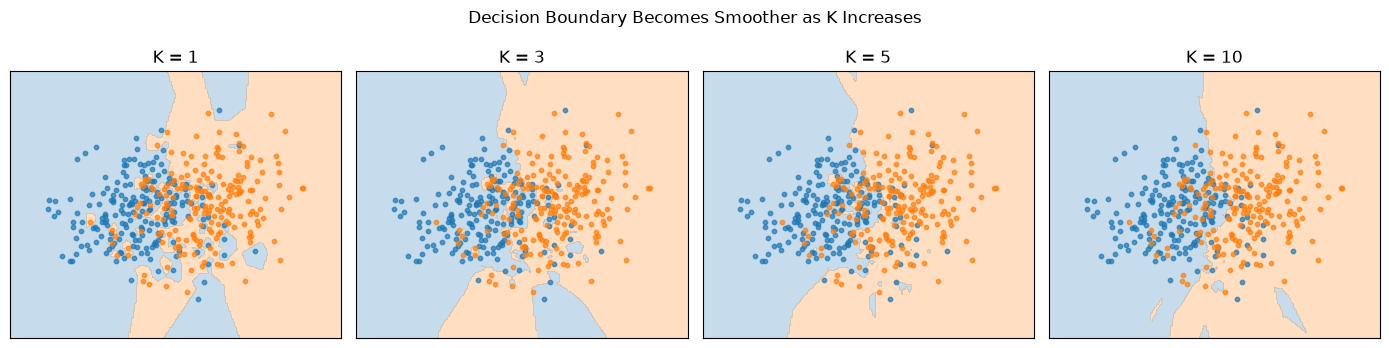

In [14]:
def plot_knn_boundary(ax, k_value):
    model = KNeighborsClassifier(n_neighbors=k_value)
    model.fit(X_boundary, y_boundary)

    x_min, x_max = X_boundary[:, 0].min() - 1, X_boundary[:, 0].max() + 1
    y_min, y_max = X_boundary[:, 1].min() - 1, X_boundary[:, 1].max() + 1
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 220),
        np.linspace(y_min, y_max, 220),
    )
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    zz = model.predict(grid_points).reshape(xx.shape)

    ax.contourf(xx, yy, zz, alpha=0.25, levels=[-0.5, 0.5, 1.5], colors=["tab:blue", "tab:orange"])
    ax.scatter(blue_points[:, 0], blue_points[:, 1], s=10, color="tab:blue", alpha=0.7)
    ax.scatter(orange_points[:, 0], orange_points[:, 1], s=10, color="tab:orange", alpha=0.7)
    ax.set_title(f"K = {k_value}")
    ax.set_xticks([])
    ax.set_yticks([])

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
for axis, k_value in zip(axes, [1, 3, 5, 10]):
    plot_knn_boundary(axis, k_value)
plt.suptitle("Decision Boundary Becomes Smoother as K Increases")
plt.tight_layout()
plt.show(block=False)
plt.close()


It is completely clear from the above figures that
- With K = 1, the boundary reacts to individual points and becomes jagged. 
- As K grows, the model listens to a wider neighborhood, so the boundary becomes smoother.


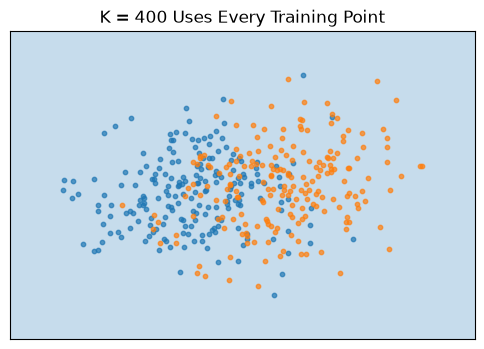

Global majority class: 0
Training accuracy if every point is predicted as the majority class: 0.5025


In [15]:
plt.figure(figsize=(6, 4))
axis = plt.gca()
plot_knn_boundary(axis, 400)
plt.title("K = 400 Uses Every Training Point")
plt.show(block=False)
plt.close()

majority_class = np.bincount(y_boundary).argmax()
majority_accuracy = np.mean(y_boundary == majority_class)
print("Global majority class:", majority_class)
print(f"Training accuracy if every point is predicted as the majority class: {majority_accuracy:.4f}")


When K equals the full dataset size, every prediction receives the same global vote.

The local structure disappears and the model collapses to the majority class. 

This is the extreme underfitting case described in the chapter.


## Step 8 - Weighted KNN

Standard KNN gives every selected neighbor one equal vote. Weighted KNN changes
this by giving closer neighbors more influence.

In Scikit-learn, this is controlled by setting `weights="distance"`.


In [16]:
knn_weighted = KNeighborsClassifier(n_neighbors=6, weights="distance")
knn_weighted.fit(X_train_scaled, y_train)

weighted_predictions = knn_weighted.predict(X_test_scaled)
weighted_accuracy = accuracy_score(y_test, weighted_predictions)

print(f"Regular KNN accuracy:  {accuracy:.2f}")
print(f"Weighted KNN accuracy: {weighted_accuracy:.2f}")


Regular KNN accuracy:  0.97
Weighted KNN accuracy: 1.00


Weighted KNN is useful when closer points should matter more than farther points.

It can help when class boundaries are fuzzy, because a faraway neighbor should not
always have the same influence as a very close neighbor.


## Step 9 - Limitations of KNN

KNN is simple and flexible, but it has important limitations:

- **Slow predictions on large datasets:** prediction requires distance calculations
  against stored training examples.
- **Memory-heavy:** the algorithm keeps the training data instead of compressing it
  into a small set of learned coefficients.
- **Sensitive to feature scales:** large-range features can dominate distance unless
  we standardize or normalize the data.
- **Weak in very high dimensions:** distances become less meaningful when there are
  too many features.
- **Sensitive to class imbalance:** if one class is much larger, neighbors are more
  likely to come from that majority class.
- **Less globally interpretable:** there is no simple coefficient table that explains
  the overall model behavior.


## Chapter Recap

In this chapter we studied K-Nearest Neighbors.

- KNN predicts from nearby training examples.
- Classification uses majority voting.
- Regression uses averaging.
- Feature scaling matters because KNN is distance-based.
- Weighted KNN gives closer neighbors more influence.
- KNN works well on smaller, well-prepared datasets, but can struggle with very
  large, high-dimensional, or imbalanced data.

